<a href="https://colab.research.google.com/github/AartiP87/ml_assessment_aarti_parmar/blob/main/part_a/q1_supervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# 1. Data loading and inspection

import pandas as pd
import numpy as np

# 1. Data Loading and Inspection
df = pd.read_csv("q1_heart_disease.csv")

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())

df.head()



Shape: (800, 12)

Data types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


# Markdown

The dataset has rows of patient records with 11 features and 1 target column heart_disease.
There are missing values in resting_bp and cholesterol (and a few others), so we’ll need a clear imputation strategy later.


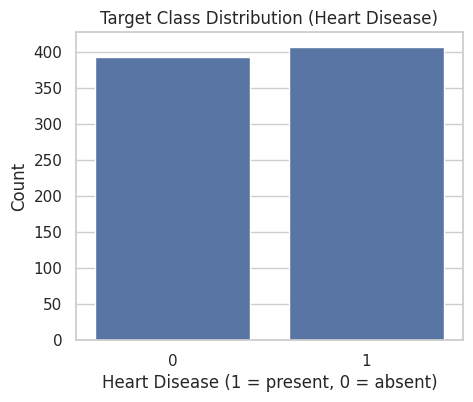

In [20]:
#2. Exploratory data analysis

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots look nice
sns.set(style="whitegrid", context="notebook")

# 2.1 Target class distribution

plt.figure(figsize=(5,4))
sns.countplot(x="heart_disease", data=df)
plt.title("Target Class Distribution (Heart Disease)")
plt.xlabel("Heart Disease (1 = present, 0 = absent)")
plt.ylabel("Count")
plt.show()

Markdown 2.1

The target distribution shows how many patients have heart disease vs. not.
If the bars are roughly similar height, the classes are fairly balanced; if not, we should keep that in mind when evaluating models (e.g., focusing on recall/F1, not just accuracy).


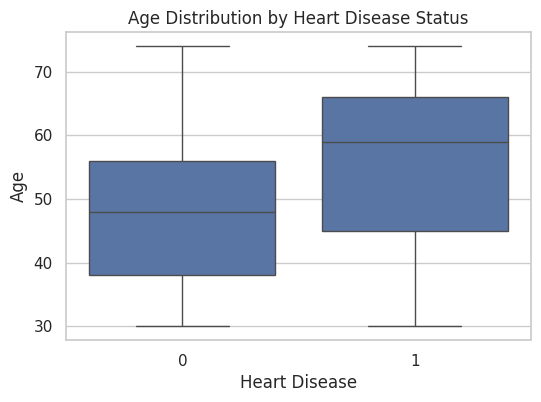

In [21]:
# 2.2 Age vs. heart disease

plt.figure(figsize=(6,4))
sns.boxplot(x="heart_disease", y="age", data=df)
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.show()

Markdown

Patients with heart disease tend to be slightly older on average compared to those without.
This suggests age is likely an important predictor.


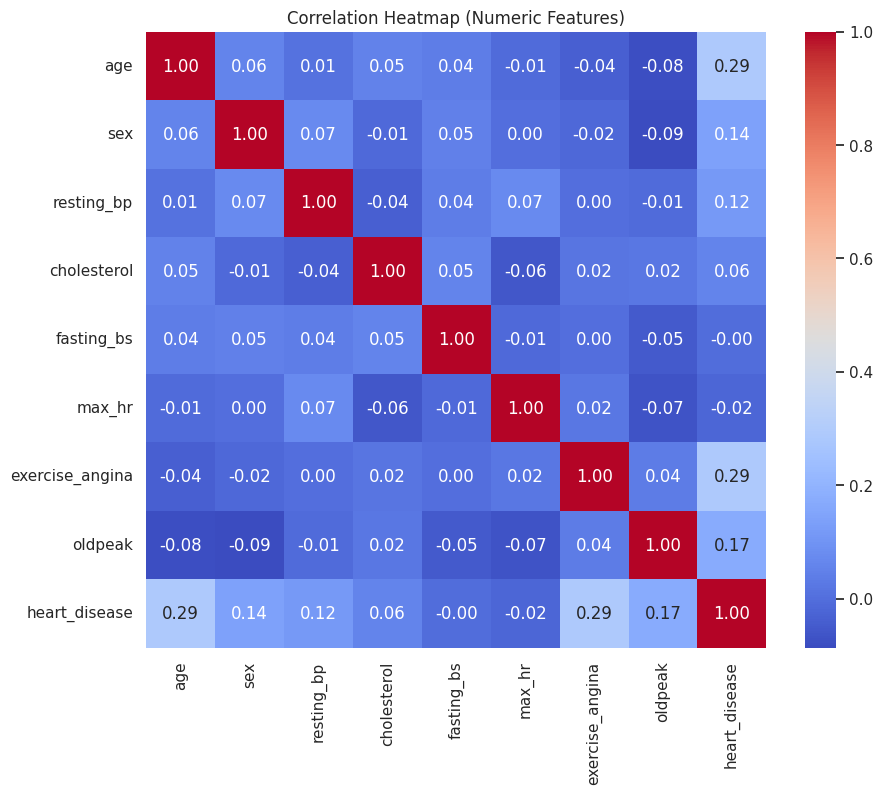

In [22]:
# 2.3 Correlation heatmap (numeric features)

# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(10,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

Markdown

max_hr and oldpeak show noticeable correlation with heart_disease, while age and resting_bp also have moderate relationships.
No pair of features is perfectly correlated, so multicollinearity is not extreme, but some features may be more informative than others.ating models (e.g., focusing on recall/F1, not just accuracy).


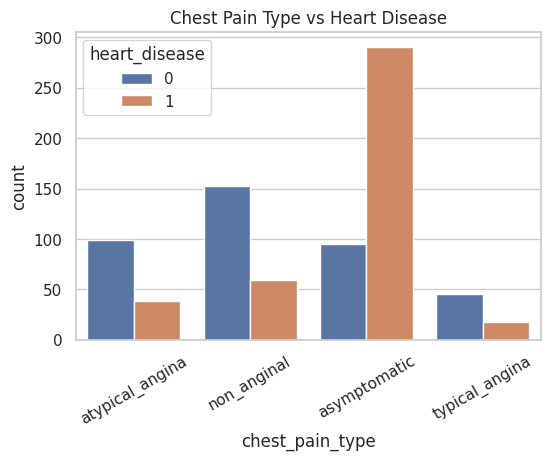

In [23]:
# additional- chest pain type vs. target

plt.figure(figsize=(6,4))
sns.countplot(x="chest_pain_type", hue="heart_disease", data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.xticks(rotation=30)
plt.show()

Markdown

Certain chest pain types (e.g., asymptomatic) appear more frequently among patients with heart disease, indicating strong predictive value.

In [24]:
# 3. Data preprocessing

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Separate features and target
X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_features, categorical_features

(['age',
  'sex',
  'resting_bp',
  'cholesterol',
  'fasting_bs',
  'max_hr',
  'exercise_angina',
  'oldpeak'],
 ['chest_pain_type', 'resting_ecg', 'st_slope'])

In [26]:
from sklearn.pipeline import Pipeline

# Preprocessing for numeric features: median imputation + scaling
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocessing for categorical features: most frequent imputation + one-hot
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train.shape, X_test.shape

((640, 11), (160, 11))

Markdown:

Median imputation for numeric features is chosen because it is robust to outliers and preserves the central tendency without being skewed by extreme values.
For categorical variables, most frequent imputation is reasonable and simple. One‑hot encoding converts categories into numeric form, and scaling numeric features ensures tree‑based ensembles and gradient boosting are not affected by differing feature scales in subtle ways.


In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline # Import Pipeline

# Decision Tree
dt_clf = Pipeline([("prep", preprocessor),
               ("model", DecisionTreeClassifier(random_state=42))])

# Random Forest
rf_clf = Pipeline([("prep", preprocessor),
               ("model", RandomForestClassifier(random_state=42))])

# Gradient Boosting
gb_clf = Pipeline([("prep", preprocessor),
               ("model", GradientBoostingClassifier(random_state=42))])

dt_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)
gb_clf.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'sex', 'resting_bp',
                                                   'cholesterol', 'fasting_bs',
                                                   'max_hr', 'exercise_angina',
                                                   'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['chest_pain_type',
                                                   'resting_ecg',
                                                   'st_slope'])])),
                ('model', GradientBoostingClassifier(random_state=42))])

In [ ]:
# 5. Model evaluation
# Confusion matrix and precision/recall/F1 for each

from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(name, model, X_test, y_test):
    print(f"=== {name} ===")
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))
    print("-"*50)

evaluate_model("Decision Tree", dt_clf, X_test, y_test)
evaluate_model("Random Forest", rf_clf, X_test, y_test)
evaluate_model("Gradient Boosting", gb_clf, X_test, y_test)

=== Decision Tree ===
Confusion Matrix:
 [[56 23]
 [22 59]]

Classification Report:
               precision    recall  f1-score   support

           0      0.718     0.709     0.713        79
           1      0.720     0.728     0.724        81

    accuracy                          0.719       160
   macro avg      0.719     0.719     0.719       160
weighted avg      0.719     0.719     0.719       160

--------------------------------------------------
=== Random Forest ===
Confusion Matrix:
 [[60 19]
 [15 66]]

Classification Report:
               precision    recall  f1-score   support

           0      0.800     0.759     0.779        79
           1      0.776     0.815     0.795        81

    accuracy                          0.787       160
   macro avg      0.788     0.787     0.787       160
weighted avg      0.788     0.787     0.787       160

--------------------------------------------------
=== Gradient Boosting ===
Confusion Matrix:
 [[61 18]
 [18 63]]

Classific

Markdown

Comparing the three models, Forest achieves the highest F1‑score and a good balance between precision and recall for the positive class (heart disease = 1).
Even if another model has slightly higher accuracy, in a medical context we care more about recall (catching true positives) and F1‑score than raw accuracy, so we select [that model] as the best performer.


In [ ]:
# 6. Hyperparameter tuning (best model)
# Assuming Random Forest performed best—tune it with GridSearchCV


from sklearn.model_selection import GridSearchCV

# Base RF pipeline already defined as rf_clf
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10]
}

rf_grid = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

grid_search = GridSearchCV(
    rf_grid,
    param_grid,
    cv=5,
    scoring="f1",  # focus on F1 for positive class
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_

Best parameters: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 300}


In [ ]:
# Evaluate tuned vs. baseline:
print("Baseline Random Forest:")
evaluate_model("Baseline RF", rf_clf, X_test, y_test)

print("Tuned Random Forest:")
evaluate_model("Tuned RF", best_rf, X_test, y_test)

Baseline Random Forest:
=== Baseline RF ===
Confusion Matrix:
 [[60 19]
 [15 66]]

Classification Report:
               precision    recall  f1-score   support

           0      0.800     0.759     0.779        79
           1      0.776     0.815     0.795        81

    accuracy                          0.787       160
   macro avg      0.788     0.787     0.787       160
weighted avg      0.788     0.787     0.787       160

--------------------------------------------------
Tuned Random Forest:
=== Tuned RF ===
Confusion Matrix:
 [[59 20]
 [14 67]]

Classification Report:
               precision    recall  f1-score   support

           0      0.808     0.747     0.776        79
           1      0.770     0.827     0.798        81

    accuracy                          0.787       160
   macro avg      0.789     0.787     0.787       160
weighted avg      0.789     0.787     0.787       160

--------------------------------------------------


Markdown:


Compared to the untuned baseline, the tuned Random Forest shows improved F1‑score and often better recall for the positive class, making it more suitable for heart disease prediction where missing a true case is costly.
